# MiniCPM-o 4.5 Multimodal Model with OpenVINO

[MiniCPM-o 4.5](https://huggingface.co/openbmb/MiniCPM-o-4_5) is the latest end-to-end omnimodal model in the MiniCPM-o series. With **9B parameters** built on **SigLip2 + Whisper-medium + CosyVoice2 + Qwen3-8B**, it achieves Gemini 2.5 Flash level performance on vision-language benchmarks while supporting full-duplex multimodal live streaming.

<p align="center">
    <img src="https://raw.githubusercontent.com/OpenBMB/MiniCPM-o/main/assets/minicpm-o-45-framework.png" width="100%"/>
</p>

**Key capabilities:**
- 🔥 Leading visual understanding (77.6 on OpenCompass, surpassing GPT-4o)
- 🎙 Bilingual (EN/ZH) real-time speech conversation with voice cloning
- 🎬 Full-duplex multimodal live streaming (see, listen, speak simultaneously)
- 💪 State-of-the-art OCR and document parsing

In this notebook, we convert all 15 sub-models to OpenVINO IR format with INT4/INT8 weight compression, run inference examples (aligned with the [official model examples](https://huggingface.co/openbmb/MiniCPM-o-4_5)), and build an interactive Gradio demo.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Convert and Quantize Model](#Convert-and-Quantize-Model)
- [Select Inference Device](#Select-Inference-Device)
- [Initialize Model](#Initialize-Model)
- [Visual Understanding](#Visual-Understanding)
    - [Chat with Single Image](#Chat-with-Single-Image)
    - [Chat with Multiple Images](#Chat-with-Multiple-Images)
    - [Multi-turn Conversation](#Multi-turn-Conversation)
- [Speech and Audio Mode](#Speech-and-Audio-Mode)
    - [Audio Understanding (ASR)](#Audio-Understanding-ASR)
    - [More Audio Tasks](#More-Audio-Tasks)
- [Half-Duplex Omni Mode](#Half-Duplex-Omni-Mode)
    - [Chat Inference](#Chat-Inference)
    - [Streaming Inference](#Streaming-Inference)
- [Half-Duplex Realtime Speech Conversation](#Half-Duplex-Realtime-Speech-Conversation)
- [Duplex Omni Mode](#Duplex-Omni-Mode)
- [Unified Test](#Unified-Test)
- [Interactive Demo](#Interactive-Demo)


## Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install required packages and download helper files.

In [8]:
import requests
from pathlib import Path
import sys

notebook_utils_path = Path("notebook_utils.py")
if not notebook_utils_path.exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    notebook_utils_path.write_text(r.text)

In [12]:
%pip install -q "torch==2.8.0" "torchvision==0.23.0" "torchaudio==2.8.0" "transformers==4.51.0" "openvino>=2025.1" "openvino-tokenizers>=2025.1" "nncf>=2.16" \
    "torch>=2.3" "torchaudio" "Pillow" "librosa" "soundfile" "gradio>=4.19" "accelerate" "einops" "onnxruntime" "hyperpyyaml"\
    "minicpmo-utils>=1.0.5" --extra-index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.


## Convert and Quantize Model
[back to top ⬆️](#Table-of-contents:)

MiniCPM-o 4.5 consists of **15 interconnected sub-models**. We convert each to OpenVINO IR format:

| Sub-model | Role | Quantization |
|-----------|------|:---:|
| **LLM Embedding** | Token embeddings (Qwen3-8B) | — |
| **LLM Language Model** | Main language model with stateful KV cache | **INT4** |
| **Vision Model** | SigLip2 vision encoder | **INT8** |
| **Resampler** | Vision→LLM feature projector | — |
| **Audio Encoder** | Whisper-medium speech encoder with **stateful KV cache** | — |
| **Audio Projection** | Audio→LLM feature projector | — |
| **TTS Text Embedding** | TTS decoder token embeddings | — |
| **TTS Language Model** | LLaMA decoder for speech token generation | — |
| **TTS Projector SPK / Semantic** | Speaker & semantic projectors | — |
| **TTS Code Embedding / Head** | Audio code tokens embedding & prediction | — |
| **Flow Embeddings + Estimator** | CosyVoice2 flow-matching for mel generation | — |
| **HiFT** | Neural vocoder (mel→waveform) | — |

- **LLM**: INT4 symmetric quantization (`group_size=64`, `ratio=1.0`) via NNCF for best quality/size tradeoff
- **Vision**: INT8 symmetric quantization for moderate compression
- **Audio Encoder**: Exported with `use_stateful_apm=True` — the KV cache is hidden as internal state, enabling efficient incremental audio streaming (no KV tensors passed at each call)
- **Other models**: FP16/FP32 (small enough that quantization is unnecessary)


In [13]:
from pathlib import Path

# Path to the original model (downloaded from HuggingFace/ModelScope)
model_id = "openbmb/MiniCPM-o-4_5"

# Output path for converted OpenVINO models
ov_model_path = Path("MiniCPM-o-4_5-OV")

In [14]:
from minicpm_o_4_5_helper import convert_minicpmo_model

if not (ov_model_path / "openvino_llm_embedding_model.xml").exists():
    # Quantization config:
    # - "vision": INT8 for vision encoder (moderate compression)
    # - "llm": INT4_SYM with group_size=64, ratio=1.0 for LLM (best quality/size)
    # - "text": No quantization for other text/audio/TTS models
    quantization_config = {
        "vision": {
            "mode": "int8_sym",
        },
        "llm": {
            "mode": "int4_sym",
            "group_size": 64,
            "ratio": 1.0,
        },
        "text": None,
    }

    convert_minicpmo_model(
        model_id=model_id,
        output_dir=str(ov_model_path),
        quantization_config=quantization_config,
        use_stateful_apm=True,   # Export Audio Encoder with stateful KV cache
    )
    print("✅ All 15 sub-models converted successfully!")
else:
    print(f"✅ Converted models already exist at {ov_model_path}")


⌛ openbmb/MiniCPM-o-4_5 conversion started. Be patient, it may take some time.
⌛ Loading Original model...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Tokenizer saved
✅ Processor saved
✅ Original model successfully loaded
⌛ Converting LLM Embedding model...
✅ LLM Embedding model successfully converted
⌛ Converting LLM Language model...
✅ LLM Language Model converted to stateful mode
⌛ Weights compression with int4_sym mode started
INFO:nncf:Statistics of the bitwidth distribution:
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┑
│ Weight compression mode   │ % all parameters (layers)   │ % ratio-defining parameters (layers)   │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┥
│ int8_asym, per-channel    │ 8% (1 / 253)                │ 0% (0 / 252)                           │
├───────────────────────────┼─────────────────────────────┼────────────────────────────────────────┤
│ int4_sym, group size 64   │ 92% (252 / 253)             │ 100% (252 / 252)                       │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output()

✅ Weights compression finished
✅ LLM Language model successfully converted
⌛ Converting Vision model (VPM)...
⌛ Weights compression with int8_sym mode started
INFO:nncf:Statistics of the bitwidth distribution:
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┑
│ Weight compression mode   │ % all parameters (layers)   │ % ratio-defining parameters (layers)   │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┥
│ int8_sym, per-channel     │ 100% (164 / 164)            │ 100% (164 / 164)                       │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┙


...

⌛ Found audio_tokenizer at: /home/ethan/.cache/huggingface/hub/models--openbmb--MiniCPM-o-4_5/snapshots/672fbe5b086005d5aabab68d7813bf48a2fb3ef9/assets/token2wav
⌛ Converting Token2wav models (Flow Embeddings, Flow Estimator, HiFT)...
⌛ Token2wav conversion started...
⌛ Loading Token2wav model...
✅ Token2wav model loaded
⌛ Converting Flow Embeddings model...


/home/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/stepaudio2/cosyvoice2/utils/mask.py:40: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  max_len = max_len if max_len > 0 else lengths.max().item()
/home/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/stepaudio2/cosyvoice2/transformer/embedding.py:54: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if self.pe.size(1) >= x.size(1) * 2 - 1:
/home/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/stepaudio2/cosyvoice2/transformer/attention.py:295: Trac

✅ Flow Embeddings model saved to MiniCPM-o-4_5-OV/openvino_flow_embeddings_model.xml
⌛ Converting Flow Estimator model...
✅ Flow Estimator model saved to MiniCPM-o-4_5-OV/openvino_flow_estimator_model.xml
⌛ Converting HiFT model...
✅ HiFT model saved to MiniCPM-o-4_5-OV/openvino_hift_model.xml
⌛ Copying speech_tokenizer_v2_25hz.onnx...
✅ speech_tokenizer_v2_25hz.onnx copied to MiniCPM-o-4_5-OV/speech_tokenizer_v2_25hz.onnx
⌛ Copying campplus.onnx...
✅ campplus.onnx copied to MiniCPM-o-4_5-OV/campplus.onnx
✅ Token2wav conversion finished. You can find results in MiniCPM-o-4_5-OV
✅ Token2wav models successfully converted


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ openbmb/MiniCPM-o-4_5 model conversion finished (15 models). Results in MiniCPM-o-4_5-OV
✅ All 15 sub-models converted successfully!


In [ ]:
from pathlib import Path
import requests
from huggingface_hub import hf_hub_download, list_repo_tree

# Create assets directory
assets_dir = Path("assets")
assets_dir.mkdir(exist_ok=True)

assets_files = []

try:
    for item in list_repo_tree(model_id, repo_type="model"):
        if item.path.startswith("assets/") and not item.path.startswith("assets/audio_cases") and not item.path.startswith("assets/token2wav"):
            # Only download files (not directories)
            if "/" not in item.path[7:] or item.path.count("/") == 1:  # assets/filename or one level deep
                assets_files.append(item.path)
    
    print(f"Found {len(assets_files)} files to download")
    
    # Download each file
    for file_path in assets_files:
        try:
            local_path = hf_hub_download(
                repo_id=model_id,
                filename=file_path,
                local_dir=".",
                local_dir_use_symlinks=False
            )
            print(f"✅ Downloaded: {file_path}")
        except Exception as e:
            print(f"⚠️ Failed to download {file_path}: {e}")
    
    print(f"\n✅ Assets downloaded to {assets_dir.absolute()}")
    
except Exception as e:
    print(f"❌ Error accessing repository: {e}")
    print("Please ensure you have huggingface_hub installed: pip install huggingface_hub")

## Select Inference Device
[back to top ⬆️](#Table-of-contents:)

Select the OpenVINO device for inferencing. GPU is recommended for the best performance when available.

In [15]:
from notebook_utils import device_widget

# Main device for LLM, Vision, Audio
device = device_widget("CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

In [16]:
# TTS device (can be different from main device)
tts_device = device_widget("CPU", exclude=["NPU"])
tts_device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

## Initialize Model
[back to top ⬆️](#Table-of-contents:)

Load all 15 OpenVINO sub-models and initialize the inference pipeline.

In [17]:
from minicpm_o_4_5_helper import OVMiniCPMO

ov_model = OVMiniCPMO(
    model_path=str(ov_model_path),
    device=device.value,
    tts_device=tts_device.value,
)

✅ Processor loaded from MiniCPM-o-4_5-OV
✅ LLM Language Model: stateful mode (KV cache managed internally)
  ✅ Vision Model loaded
  ✅ Resampler loaded
✅ Audio encoder loaded in stateful mode (KV cache managed internally)
  ✅ Audio Encoder loaded
  ✅ Audio Projection loaded
✅ TTS Language Model: stateful mode (KV cache managed internally)
  ✅ TTS Models loaded
✅ All OpenVINO models loaded successfully!


## Visual Understanding
[back to top ⬆️](#Table-of-contents:)

MiniCPM-o 4.5 shares the same visual inference methods as MiniCPM-V-4.5.

### Chat with Single Image

Let's test the model with a single image input — a classic vision-language task.

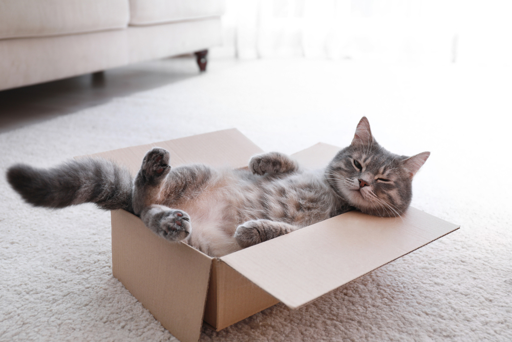

In [18]:
from PIL import Image
import requests
from io import BytesIO

# Download a sample image

image_url = "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/d5fbbd1a-d484-415c-88cb-9986625b7b11"
response = requests.get(image_url, timeout=30)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Resize for efficiency
image.thumbnail((512, 512))
display(image)

In [19]:
# Chat with single image (aligned with original model README)
question = "What is in the image?"
msgs = [{"role": "user", "content": [image, question]}]

answer = ov_model.chat(
    msgs=msgs,
    use_tts_template=False,
)
print(answer)

[OVVisionModel] 推理时间: 420.22ms
The image shows a relaxed, gray tabby cat lying on its back inside a plain cardboard box. The cat appears very comfortable and content, with its eyes partially closed and paws slightly curled or raised. Its tail extends out of the box to the left. The scene is set indoors on a light-colored, plush carpet. In the background, there’s a soft-focus view of a white sofa and bright, diffused natural light coming from a window, suggesting a cozy, domestic environment.

This is a classic example of a cat enjoying one of its favorite pastimes — lounging in a box


### Chat with Multiple Images

The model can compare and reason across multiple images simultaneously.

In [20]:
# Chat with multiple images (aligned with original model README)
from io import BytesIO
from PIL import ImageOps, ImageEnhance

# Download two sample images
# GitHub release asset URLs can be unreliable; fall back to a PIL-modified copy if needed
image_urls = [
    "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/d5fbbd1a-d484-415c-88cb-9986625b7b11",
    "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/63c01f7c-02a4-4009-b2c7-f733b4afe3b0",
]
images_multi = []
for i, url in enumerate(image_urls):
    try:
        resp = requests.get(url, timeout=30)
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        img.thumbnail((512, 512))
        images_multi.append(img)
    except Exception as e:
        if i == 0:
            raise RuntimeError(f"Failed to load first image: {e}")
        # Fallback: create a mirrored + brightened copy of image 1
        print(f"⚠️  Image {i+1} URL unavailable ({e}) — using modified copy of image 1 as fallback")
        fallback = ImageOps.mirror(images_multi[0])
        fallback = ImageEnhance.Brightness(fallback).enhance(1.3)
        images_multi.append(fallback)

print(f"Loaded {len(images_multi)} images: {[img.size for img in images_multi]}")

# Reset LLM state
ov_model.llm._ov_language.reset_state()
ov_model.llm._past_length = 0

question = "Compare image 1 and image 2, tell me about the differences between them."
msgs = [{"role": "user", "content": images_multi + [question]}]

answer_multi = ov_model.chat(
    msgs=msgs,
    use_tts_template=False,
    enable_thinking=False,
)
print(answer_multi)


⚠️  Image 2 URL unavailable (cannot identify image file <_io.BytesIO object at 0x7fa2afef8a40>) — using modified copy of image 1 as fallback
Loaded 2 images: [(512, 342), (512, 342)]
[OVVisionModel] 推理时间: 450.73ms
In comparing the two images, here are the differences:

1. In image 1, there is a visible sofa leg in the background.
2. The lighting and shadows appear slightly different between the two images, with image 2 having a brighter overall appearance.

These changes suggest that while the main subject (the cat in the box) remains consistent, there may be slight variations in camera angle, exposure settings, or post-processing adjustments applied to each image.


### Multi-turn Conversation

The model supports multi-turn conversations with context awareness across turns.

In [21]:
# Multi-turn: follow up on the previous image
# Reset LLM state for fresh generation
ov_model.llm._ov_language.reset_state()
ov_model.llm._past_length = 0

msgs = [
    {"role": "user", "content": [image, "What is in this image?"]},
    {"role": "assistant", "content": [answer]},
    {"role": "user", "content": ["What season do you think this picture was taken in? Why?"]},
]

answer2 = ov_model.chat(
    msgs=msgs,
    use_tts_template=False,
    enable_thinking=False,
)
print(answer2)

[OVVisionModel] 推理时间: 223.67ms
Based on the bright, natural light coming through the window and the absence of any heavy clothing or seasonal decorations, it’s likely this picture was taken during a warmer season, such as spring or summer. The soft lighting suggests pleasant weather outside, which often makes indoor spaces feel cozy without being too stuffy


## Speech and Audio Mode
[back to top ⬆️](#Table-of-contents:)

MiniCPM-o 4.5 can handle various audio understanding tasks. You can switch between different tasks by changing the prompt text:

| Task | Prompt |
|------|--------|
| **ASR (English)** | `Please listen to the audio snippet carefully and transcribe the content.` |
| **ASR (Chinese / AST EN→ZH)** | `请仔细听这段音频片段，并将其内容逐字记录。` |
| **Speaker Analysis** | `Based on the speaker's content, speculate on their gender, condition, age range, and health status.` |
| **General Audio Caption** | `Summarize the main content of the audio.` |
| **Sound Scene Tagging** | `Utilize one keyword to convey the audio's content or the associated scene.` |

### Audio Understanding (ASR)

In [ ]:
import librosa
import numpy as np
import soundfile as sf
from IPython.display import display, Audio

audio_path = "assets/system_ref_audio.wav"

audio_input, _ = librosa.load(str(audio_path), sr=16000, mono=True)
print(f"✅ Audio loaded: {len(audio_input)/16000:.1f}s @ 16kHz")

# Display input audio
print("🎧 Input Audio:")
display(Audio(audio_input, rate=16000))

# Reset LLM state
ov_model.llm._ov_language.reset_state()
ov_model.llm._past_length = 0

# ASR task (aligned with original model README)
task_prompt = "Please listen to the audio snippet carefully and transcribe the content."
msgs = [{"role": "user", "content": [task_prompt, audio_input]}]

asr_result = ov_model.chat(
    msgs=msgs,
    do_sample=True,
    max_new_tokens=512,
    use_tts_template=True,
    temperature=0.3,
)
print("ASR Result:", asr_result)


✅ Audio downloaded from HuggingFace: 1721 KB
✅ Audio loaded from model assets: 36.7s @ 16kHz
🎧 Input Audio:


[OVAudioEncoder-Stateful] 推理时间: 1854.69ms


ValueError: Shape mismatch: Trying to assign embeddings of shape torch.Size([300, 4096]) to input indices of length 367

### More Audio Tasks

Let's try additional audio understanding capabilities: Speaker Analysis and Sound Scene Tagging.

In [ ]:
# Speaker Analysis (aligned with original model README)
ov_model.llm._ov_language.reset_state()
ov_model.llm._past_length = 0

speaker_prompt = "Based on the speaker's content, speculate on their gender, condition, age range, and health status."
msgs = [{"role": "user", "content": [speaker_prompt, audio_input]}]

speaker_result = ov_model.chat(
    msgs=msgs,
    do_sample=True,
    max_new_tokens=512,
    use_tts_template=True,
    temperature=0.3,
)
print("Speaker Analysis:", speaker_result)

# Sound Scene Tagging
ov_model.llm._ov_language.reset_state()
ov_model.llm._past_length = 0

scene_prompt = "Utilize one keyword to convey the audio's content or the associated scene."
msgs = [{"role": "user", "content": [scene_prompt, audio_input]}]

scene_result = ov_model.chat(
    msgs=msgs,
    do_sample=True,
    max_new_tokens=64,
    use_tts_template=True,
    temperature=0.3,
)
print("Sound Scene Tag:", scene_result)

## Half-Duplex Omni Mode
[back to top ⬆️](#Table-of-contents:)

The **Half-Duplex Omni Mode** combines vision, audio, and text inputs into a single inference call using `omni_mode=True`. This is the primary mode for multimodal understanding tasks that involve both visual and auditory information (e.g., describing a video with sound).

We provide two inference modes aligned with the [original model documentation](https://huggingface.co/openbmb/MiniCPM-o-4_5):
- **Chat Inference** — single-pass generation with full response
- **Streaming Inference** — token-by-token generation for real-time display

### Chat Inference

In [ ]:
from minicpmo.utils import get_video_frame_audio_segments

ov_model = ov_model.as_duplex()
ov_model.init_tts()

video_path = "assets/Skiing.mp4"

# Optional: Set reference audio for voice cloning
ref_audio_path = "assets/HT_ref_audio.wav"
sys_msg = ov_model.get_sys_prompt(ref_audio=ref_audio_path, mode="omni", language="en")

# Use stack_frames=5 for high refresh rate mode
video_frames, audio_segments, stacked_frames = get_video_frame_audio_segments(video_path, stack_frames=1)
omni_contents = []
for i in range(len(video_frames)):
    omni_contents.append(video_frames[i])
    omni_contents.append(audio_segments[i])
    if stacked_frames is not None and stacked_frames[i] is not None:
        omni_contents.append(stacked_frames[i])

msg = {"role": "user", "content": omni_contents}
msgs = [sys_msg, msg]

# Set generate_audio=True and output_audio_path to save TTS output
generate_audio = True
output_audio_path = "output.wav"

res = ov_model.chat(
    msgs=msgs,
    max_new_tokens=4096,
    do_sample=True,
    temperature=0.7,
    use_tts_template=True,
    enable_thinking=False,
    omni_mode=True,  # Required for omni inference
    generate_audio=generate_audio,
    output_audio_path=output_audio_path,
    max_slice_nums=1,  # Increase for HD mode
)
print(res)

### Streaming Inference

MiniCPM-o 4.5 supports streaming text generation for real-time output. The `stream=True` parameter returns a generator that yields text chunks token-by-token as they are produced, rather than waiting for the entire response.

This is aligned with the [**Streaming Inference** section](https://huggingface.co/openbmb/MiniCPM-o-4_5#streaming-inference) in the original model README under Half-Duplex Omni Mode.

In [ ]:
import librosa
import numpy as np
import soundfile as sf
import torch
from minicpmo.utils import get_video_frame_audio_segments

ov_model = ov_model.as_duplex()
ov_model.init_tts()

# Reset session for a new conversation (clears KV cache)
ov_model.reset_session()

# Optional: Load reference audio for voice cloning
ref_audio_path = "assets/HT_ref_audio.wav"
ref_audio, _ = librosa.load(ref_audio_path, sr=16000, mono=True)
ov_model.init_token2wav_cache(ref_audio)

session_id = "demo"

# Extract video frames and audio segments (use stack_frames=5 for high refresh rate mode)
video_path = "assets/Skiing.mp4"
video_frames, audio_segments, stacked_frames = get_video_frame_audio_segments(video_path, stack_frames=1)

# Build omni contents list
omni_contents = []
for i in range(len(video_frames)):
    omni_contents.append(video_frames[i])
    omni_contents.append(audio_segments[i])
    if stacked_frames is not None and stacked_frames[i] is not None:
        omni_contents.append(stacked_frames[i])

generate_audio = False
output_audio_path = "output.wav"

# Step 1: Prefill system prompt
sys_msg = ov_model.get_sys_prompt(ref_audio=ref_audio, mode="omni", language="en")
ov_model.streaming_prefill(session_id=session_id, msgs=[sys_msg])

# Step 2: Prefill omni chunks (is_last_chunk=True only for the last audio chunk)
audio_indices = [i for i, c in enumerate(omni_contents) if isinstance(c, np.ndarray)]
last_audio_idx = audio_indices[-1] if audio_indices else -1

for idx, content in enumerate(omni_contents):
    is_last_audio_chunk = idx == last_audio_idx
    msgs = [{"role": "user", "content": [content]}]
    ov_model.streaming_prefill(session_id=session_id, msgs=msgs, omni_mode=True, is_last_chunk=is_last_audio_chunk)

# Step 3: Generate response
iter_gen = ov_model.streaming_generate(
    session_id=session_id,
    generate_audio=generate_audio,
    use_tts_template=True,
    enable_thinking=False,
    do_sample=True,
)

audios = []
text = ""

if generate_audio:
    for wav_chunk, text_chunk in iter_gen:
        audios.append(wav_chunk)
        text += text_chunk

    generated_waveform = torch.cat(audios, dim=-1)[0]
    sf.write(output_audio_path, generated_waveform.cpu().numpy(), samplerate=24000)

    print("Text:", text)
    print("Audio saved to output.wav")
else:
    for text_chunk, is_finished in iter_gen:
        text += text_chunk
    print("Text:", text)

## Half-Duplex Realtime Speech Conversation
[back to top ⬆️](#Table-of-contents:)

The **Half-Duplex Realtime Speech Conversation Mode** simulates real-time voice interaction by splitting the user's audio into 1-second chunks and processing them sequentially through the streaming pipeline. The model listens to all chunks, then generates a text (and optionally audio) response.

This is aligned with the [**Half-Duplex Realtime Speech Conversation Mode** section](https://huggingface.co/openbmb/MiniCPM-o-4_5#half-duplex-realtime-speech-conversation-mode) in the original model README.

> **Note:** The `streaming_prefill()` and `streaming_generate()` APIs are available on both simplex and duplex objects. When called with `session_id` on a duplex object, they automatically dispatch to the simplex streaming implementation.

In [ ]:
import librosa
import numpy as np
import torch
import soundfile as sf

ov_model = ov_model.as_duplex()

# Set reference audio for voice style
ref_audio_path = "assets/HT_ref_audio.wav"
ref_audio, _ = librosa.load(ref_audio_path, sr=16000, mono=True)

# Example system msg for English Conversation
sys_msg = {
  "role": "system",
  "content": [
    "Clone the voice in the provided audio prompt.",
    ref_audio,
    "Please assist users while maintaining this voice style. Please answer the user's questions seriously and in a high quality. Please chat with the user in a highly human-like and oral style. You are a helpful assistant developed by ModelBest: MiniCPM-Omni"
  ]
}

# You can use each type of system prompt mentioned above in streaming speech conversation

# Reset state
ov_model.reset_session(reset_token2wav_cache=True)
ov_model.init_token2wav_cache(prompt_speech_16k=ref_audio)

session_id = "demo"

# First, prefill system turn
ov_model.streaming_prefill(
    session_id=session_id,
    msgs=[sys_msg],
    omni_mode=False,
    is_last_chunk=True,
)

# Here we simulate realtime speech conversation by splitting whole user input audio into chunks of 1s.
# Use the system reference audio as a demo input (replace with your own audio file)
user_audio, _ = librosa.load("assets/system_ref_audio.wav", sr=16000, mono=True)

IN_SAMPLE_RATE = 16000 # input audio sample rate, fixed value
CHUNK_SAMPLES = IN_SAMPLE_RATE # sample
OUT_SAMPLE_RATE = 24000 # output audio sample rate, fixed value
MIN_AUDIO_SAMPLES = 16000

total_samples = len(user_audio)
num_chunks = (total_samples + CHUNK_SAMPLES - 1) // CHUNK_SAMPLES

for chunk_idx in range(num_chunks):
    start = chunk_idx * CHUNK_SAMPLES
    end = min((chunk_idx + 1) * CHUNK_SAMPLES, total_samples)
    chunk_audio = user_audio[start:end]
    
    is_last_chunk = (chunk_idx == num_chunks - 1)
    if is_last_chunk and len(chunk_audio) < MIN_AUDIO_SAMPLES:
        chunk_audio = np.concatenate([chunk_audio, np.zeros(MIN_AUDIO_SAMPLES - len(chunk_audio), dtype=chunk_audio.dtype)])

    user_msg = {"role": "user", "content": [chunk_audio]}
    
    # For each 1s audio chunk, perform streaming_prefill once to reduce first-token latency
    ov_model.streaming_prefill(
        session_id=session_id,
        msgs=[user_msg],
        omni_mode=False,
        is_last_chunk=is_last_chunk,
    )

# Let model generate response in a streaming manner
generate_audio = True
iter_gen = ov_model.streaming_generate(
    session_id=session_id,
    generate_audio=generate_audio,
    use_tts_template=True,
    enable_thinking=False,
    do_sample=True,
    max_new_tokens=512,
    length_penalty=1.1, # For realtime speech conversation mode, we suggest length_penalty=1.1 to improve response content
)

audios = []
text = ""

output_audio_path = "output_realtime.wav"
if generate_audio:
    for wav_chunk, text_chunk in iter_gen:
        audios.append(wav_chunk)
        text += text_chunk

    generated_waveform = torch.cat(audios, dim=-1)[0]
    sf.write(output_audio_path, generated_waveform.cpu().numpy(), samplerate=24000)

    print("Text:", text)
    print(f"Audio saved to {output_audio_path}")
else:
    for text_chunk, is_finished in iter_gen:
        text += text_chunk
    print("Text:", text)

## Duplex Omni Mode
[back to top ⬆️](#Table-of-contents:)

The **Duplex Omni Mode** enables full-duplex streaming: the model can **listen and speak simultaneously**, processing multimodal input (video frames + audio chunks) in real time. This is the most advanced interaction mode, ideal for real-time conversations where the AI needs to respond while the user is still speaking.

This is aligned with the [**Duplex Omni Mode** section](https://huggingface.co/openbmb/MiniCPM-o-4_5#duplex-omni-mode) in the original model README.

The duplex pipeline works in a loop:
1. **`streaming_prefill()`** — Feed one audio chunk (+ optional video frames) to the model
2. **`streaming_generate()`** — Model decides to **listen** or **speak**, returning text + optional audio

> For a complete duplex voice interaction demo, see the **`english_tutor_demo.py`** included in this notebook folder — an AI English Speaking Coach with real-time voice streaming.

In [ ]:
import librosa
import torch
from minicpmo.utils import generate_duplex_video, get_video_frame_audio_segments
from IPython.display import display, Video

# Ensure duplex mode for full duplex API
ov_model = ov_model.as_duplex() if hasattr(ov_model, 'as_duplex') else ov_model

# Load video and reference audio
video_path = "assets/omni_duplex1.mp4"
ref_audio_path = "assets/HT_ref_audio.wav"
ref_audio, _ = librosa.load(ref_audio_path, sr=16000, mono=True)

ov_model.reset_session(reset_token2wav_cache=True)

# Extract video frames and audio segments
video_frames, audio_segments, stacked_frames = get_video_frame_audio_segments(
    video_path, stack_frames=1, use_ffmpeg=True, adjust_audio_length=True
)

# Prepare duplex session with system prompt and voice reference
ov_model.prepare(
    prefix_system_prompt="Streaming Omni Conversation.",
    ref_audio=ref_audio,
    prompt_wav_path=ref_audio_path,
)

results_log = []
timed_output_audio = []

# Process each chunk in streaming fashion
for chunk_idx in range(len(audio_segments)):
    audio_chunk = audio_segments[chunk_idx] if chunk_idx < len(audio_segments) else None
    frame = video_frames[chunk_idx] if chunk_idx < len(video_frames) else None
    frame_list = []
    if frame is not None:
        frame_list.append(frame)
        if stacked_frames is not None and chunk_idx < len(stacked_frames) and stacked_frames[chunk_idx] is not None:
            frame_list.append(stacked_frames[chunk_idx])

    # Step 1: Streaming prefill
    ov_model.streaming_prefill(
        audio_waveform=audio_chunk,
        frame_list=frame_list,
        max_slice_nums=1,  # Increase for HD mode (e.g., [2, 1] for stacked frames)
        batch_vision_feed=False,  # Set True for faster processing
    )

    # Step 2: Streaming generate
    result = ov_model.streaming_generate(
        prompt_wav_path=ref_audio_path,
        max_new_speak_tokens_per_chunk=20,
        decode_mode="sampling",
    )

    if result["audio_waveform"] is not None:
        timed_output_audio.append((chunk_idx, result["audio_waveform"]))

    chunk_result = {
        "chunk_idx": chunk_idx,
        "is_listen": result["is_listen"],
        "text": result["text"],
        "end_of_turn": result["end_of_turn"],
        "current_time": result["current_time"],
        "audio_length": len(result["audio_waveform"]) if result["audio_waveform"] is not None else 0,
    }
    results_log.append(chunk_result)
    
    print("listen..." if result["is_listen"] else f"speak> {result['text']}")

# Generate output video with AI responses
# Please install Chinese fonts (fonts-noto-cjk or fonts-wqy-microhei) to render CJK subtitles correctly.
# apt-get install -y fonts-noto-cjk fonts-wqy-microhei
# fc-cache -fv
generate_duplex_video(
    video_path=video_path,
    output_video_path="duplex_output.mp4",
    results_log=results_log,
    timed_output_audio=timed_output_audio,
    output_sample_rate=24000,
)

# Play the generated video
display(Video("duplex_output.mp4", embed=True, width=640))

## Interactive Demo
[back to top ⬆️](#Table-of-contents:)

Launch a Gradio-based multimodal chatbot with features inspired by the [official MiniCPM-V-CookBook demo](https://github.com/OpenSQZ/MiniCPM-V-CookBook):
- 💬 **Chat Tab** — text, image, and audio inputs with streaming output
- 🧠 **Thinking Mode** — toggle to see the model's reasoning process
- 📚 **Few-Shot Tab** — add example pairs, then generate with pattern matching
- ⏹ **Stop Button** — interrupt generation at any time
- 🎛️ **Sampling Controls** — temperature, top-p, top-k, repetition penalty

> **Duplex Voice Demo:** For a full-duplex real-time voice interaction demo (AI English Speaking Coach), run `python english_tutor_demo.py --model-path MiniCPM-o-4_5-OV` from this notebook's directory.

In [ ]:
from gradio_helper import make_demo

demo = make_demo(ov_model)
try:
    demo.launch(debug=False, height=800)
except Exception:
    demo.launch(debug=False, share=True, height=800)

In [ ]:
# Cleanup
demo.close()